# Import our Python package and other functions

In [1]:
# python3 -m pip install PyMHSS

from PyMHSS import *
import matplotlib.pyplot as plt
from statsmodels.graphics import tsaplots

# Simulate an AR (1) Poisson process

In [2]:
def simulate_AR1_poisson(N, d):

    """
    Simulate synthetic data from an AR(1) poisson process.

    Parameters
    ----------

    N : number of observations
    d : number of parameters in the linear predictor
    """
    
    # y_t ~ Poisson(log(1 + exp(alpha + beta * y_{t-1})) 
    theta = np.array([2, .6])
    y = np.zeros(N+1)
    x = np.zeros(N*d)
    x = np.array(x).reshape(N, d)
    x[:, 0] = np.repeat(1, N)

    for i in range(N):
        x[i,1] = y[i]
        eta = x[i, :] @ theta
        y[i+1] = np.random.poisson(np.log(1 + np.exp(eta)))
    
    y = np.delete(y, 0)

    return {
        'y': y,
        'x': x,
        'theta': theta
    }

In [3]:
N=10000
d=2
model='poisson'

# Generate simulated data
data = simulate_AR1_poisson(N, d)
y = data.get('y')
x = data.get('x')

# Find theta_hat
theta_hat, V = get_theta_hat_and_var_cov_matrix(model, x, y, basic_lr=1/(3*N))

0
tf.Tensor(215746.0, shape=(), dtype=float32)
tf.Tensor(7.191533, shape=(), dtype=float32)
100
tf.Tensor(196.6182, shape=(), dtype=float32)
tf.Tensor(0.006553948, shape=(), dtype=float32)
200
tf.Tensor(31.504921, shape=(), dtype=float32)
tf.Tensor(0.0010501742, shape=(), dtype=float32)
300
tf.Tensor(5.2973213, shape=(), dtype=float32)
tf.Tensor(0.00017666817, shape=(), dtype=float32)
400
tf.Tensor(0.89928484, shape=(), dtype=float32)
tf.Tensor(3.0040741e-05, shape=(), dtype=float32)
500
tf.Tensor(0.15033433, shape=(), dtype=float32)
tf.Tensor(4.9471855e-06, shape=(), dtype=float32)
600
tf.Tensor(0.025019988, shape=(), dtype=float32)
tf.Tensor(8.34465e-07, shape=(), dtype=float32)
700
tf.Tensor(0.009421766, shape=(), dtype=float32)
tf.Tensor(2.3841858e-07, shape=(), dtype=float32)


# Time-series, ACF and PACF plots

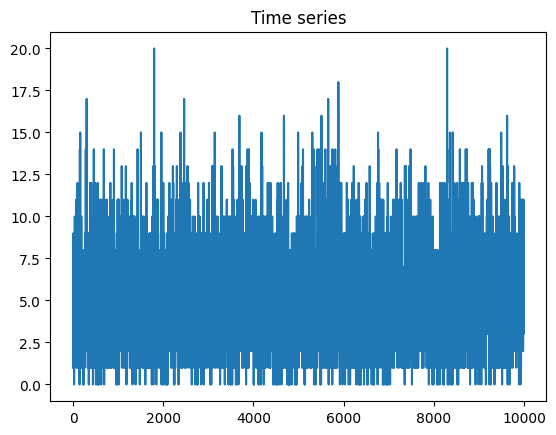

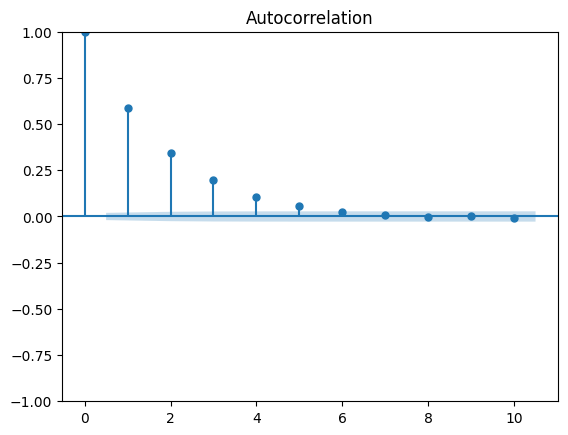

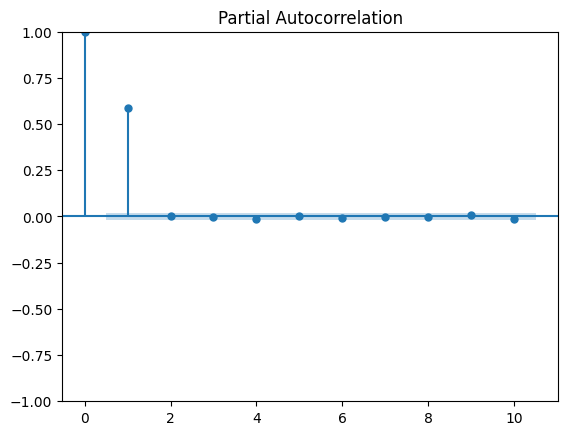

In [4]:
plt.plot(y)
plt.title('Time series')
plt.show()

fig = tsaplots.plot_acf(y, lags=10)
plt.show()

fig = tsaplots.plot_pacf(y, lags=10)
plt.show()

# Run MH-SS-1, MH-SS-2 and RWM

In [5]:
implementation = 'vectorised'
npost = 10000 # for a quick run

mh_ss_cv1 = MH_SS(y, x, V, x0 = theta_hat, model=model, phi_function = 'min', taylor_order = 1, chi=0, nburn=0, npost=npost, implementation=implementation, calculate_ksd=True)
mh_ss_cv2 = MH_SS(y, x, V, x0 = theta_hat, model=model, phi_function = 'min', taylor_order = 2, chi=0, nburn=0, npost=npost, implementation=implementation, calculate_ksd=True)
rwm = RWM(y, x, V, x0 = theta_hat, model=model, nburn=0, npost=npost, implementation=implementation, calculate_ksd=True)

print(np.mean(mh_ss_cv1.get('BoverN')*N))
print(np.mean(mh_ss_cv2.get('BoverN')*N))

Running: 100%|█████████████████████| 10000/10000 [00:07<00:00, 1283.70it/s]


1191.2257
224.6261


In [7]:
print(mh_ss_cv1.get('KSD'))
print(mh_ss_cv2.get('KSD'))
print(rwm.get('KSD'))

5.417793273925781
16.29865264892578
4.047072410583496


# Density plot

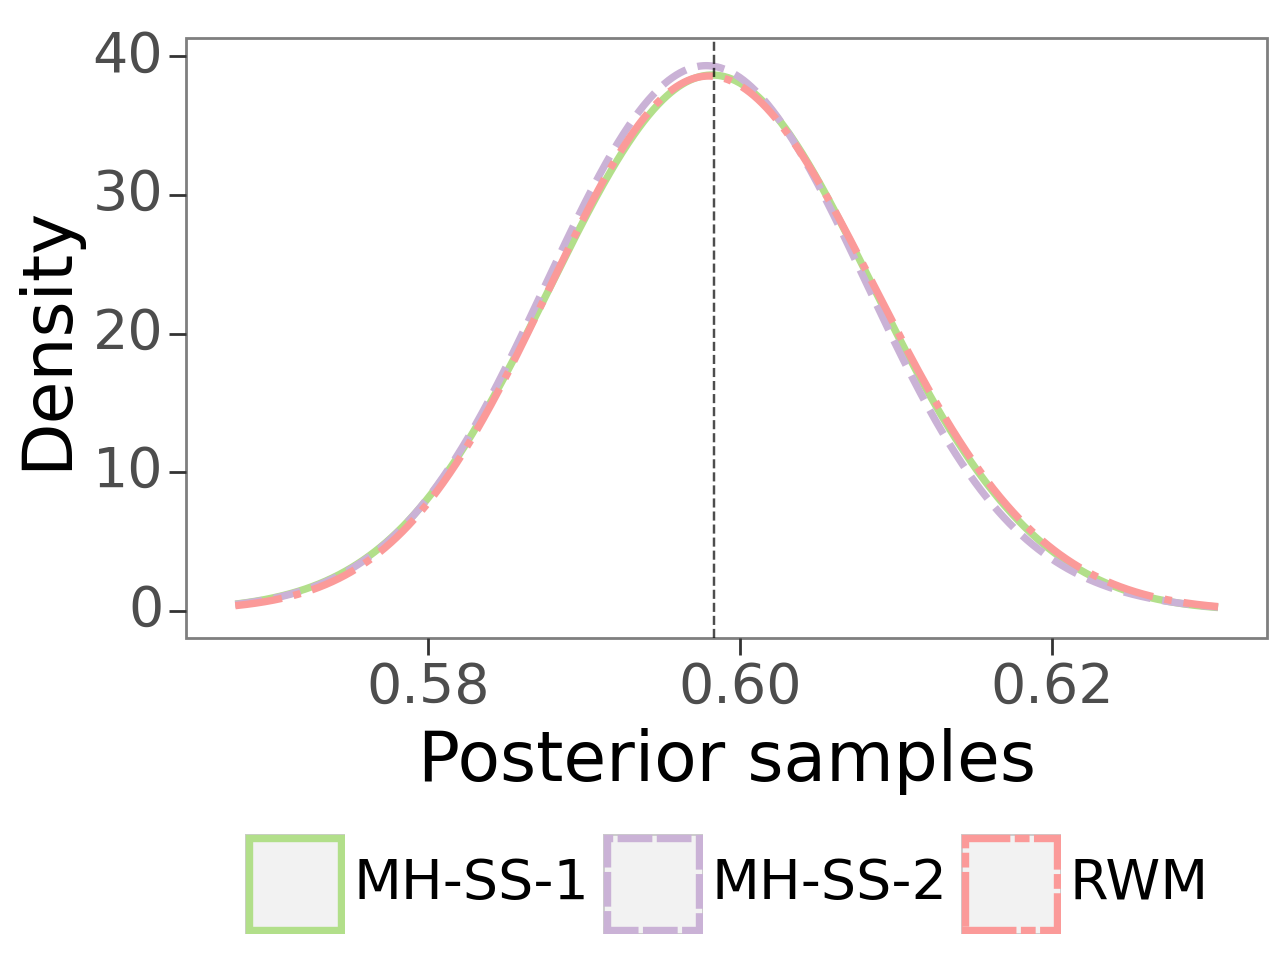

<Figure Size: (640 x 480)>

In [10]:
par = 1

x1 = mh_ss_cv1.get('parameters')[:, par]
y1 = mh_ss_cv2.get('parameters')[:, par]
z = rwm.get('parameters')[:, par]

pd_x1 = pd.DataFrame(x1)
pd_x1['algorithm'] = 'MH-SS-1'
pd_x1.columns = ['samples', 'algorithm']

pd_y1 = pd.DataFrame(y1)
pd_y1['algorithm'] = 'MH-SS-2'
pd_y1.columns = ['samples', 'algorithm']

pd_z = pd.DataFrame(z)
pd_z['algorithm'] = 'RWM'
pd_z.columns = ['samples', 'algorithm']

df = pd.concat([pd_x1,
                pd_y1,
                pd_z], axis=0)

height_plot = 8
width_plot = 12

plot = (ggplot(df) + 
aes(x='samples', colour='algorithm', linetype='algorithm') +  
    geom_density(adjust=5, size=1.5) +
labs(
      y = 'Density',
    #   x = r'log$_{10} N$'
      x = 'Posterior samples'
      ) + 
theme_bw(base_size = 25) +
theme(plot_title = element_text(size = 25, hjust = 0.5),
    strip_text_y = element_text(angle = 0),
    legend_position = 'bottom',
    legend_title = element_blank(),
    panel_grid_major = element_blank(),
    panel_grid_minor = element_blank()) + 
    scale_color_manual(values=["#B2DF8A", "#CAB2D6", "#FB9A99"])
    +
geom_vline(xintercept = theta_hat[par], linetype='dashed', alpha=0.7)
)

plot